<h1 style="height:60px;">Training and Evaluating ModelNetV2 and ResNet34</h1>

In [1]:
from torchvision.datasets import ImageFolder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,random_split
from torchvision import transforms,models,datasets
import matplotlib.pyplot as plt
import numpy as np
from torch import optim
import os
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns


preprocess=transforms.Compose(
    [
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
         mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
]
)

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset=ImageFolder(
    os.path.abspath("caltech101"),
    transform=preprocess,
)
total_size=len(dataset)
train_size=int(0.7*total_size)
val_size=int(0.15*total_size)
test_size=total_size-train_size-val_size

train_dataset,val_dataset,test_dataset=random_split(dataset,[train_size,val_size,test_size])
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=64,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False)

criterion=nn.CrossEntropyLoss()

model1=models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model2=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

num_classes=len(dataset.classes)
model1.fc=nn.Linear(model1.fc.in_features,num_classes)
model2.classifier[1]=nn.Linear(model2.classifier[1].in_features,num_classes)

model1=model1.to(device)
model2=model2.to(device)

print(device)
for i in model1.parameters():
    i.requires_grad=False
for i in model1.fc.parameters():
    i.requires_grad=True


for i in model2.parameters():
    i.requires_grad=False
for i in model2.classifier[1].parameters():
    i.requires_grad=True

optimizer1=optim.Adam(model1.fc.parameters(),lr=0.003)
optimizer2=optim.Adam(model2.classifier[1].parameters())
epochs=3

for epoch in range(epochs):

    model1.train()
    running_loss1=0
    total=0
    correct_answer=0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer1.zero_grad()
        output1=model1(images)
        loss1=criterion(output1,labels)
        loss1.backward()
        optimizer1.step()
        running_loss1+=loss1.item()*labels.size(0)
        total+=labels.size(0)
        probability,classes=torch.max(output1,1)
        correct_answer+=(classes==labels).sum().item()
    print(f"Training Loss Model 1: {running_loss1/total}")
    print(f"Training Accuracy Model 1: {(correct_answer/total)*100}%")
    print("")
    model1.eval()
    with torch.no_grad():
        running_loss1=0
        correct_answer=0
        total=0
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            output1=model1(images)
            loss1=criterion(output1,labels)
            running_loss1+=loss1.item()*labels.size(0)
            probability,classes=torch.max(output1,1)
            total+=labels.size(0)
            correct_answer+=(classes==labels).sum().item()
        print(f"Evaluation Loss Model 1: {running_loss1/total}")
        print(f"Evaluation Accuracy Model 1: {(correct_answer/total)*100}%")
        print("")



            

       
for epoch in range(epochs):

    model2.train()
    total=0
    running_loss2=0
    correct_answer=0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer2.zero_grad()
        output2=model2(images)
        loss2=criterion(output2,labels)
        loss2.backward()
        optimizer2.step()
        running_loss2+=loss2.item()*labels.size(0)
        total+=labels.size(0)
        probability,classes=torch.max(output2,1)
      
        correct_answer+=(classes==labels).sum().item()
    print(f"Training Loss Model 2: {running_loss2/total}")
    print(f"Training Accuracy Model 2: {(correct_answer/total)*100}%")
    print("")
    model2.eval()
    with torch.no_grad():
        running_loss2=0
        correct_answer=0
        total=0
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            output2=model2(images)
            loss2=criterion(output2,labels)
            running_loss2+=loss2.item()*labels.size(0)
            probability,classes=torch.max(output2,1)
            total+=labels.size(0)
            correct_answer+=(classes==labels).sum().item()
            
        print(f"Evaluation Loss Model 2: {(running_loss2/total)}")
        print(f"Evaluation Accuracy Model 2: {(correct_answer/total)*100}%")
        print("")



cuda
Training Loss Model 1: 1.4285225549340248
Training Accuracy Model 1: 70.90625%

Evaluation Loss Model 1: 0.5235546575159509
Evaluation Accuracy Model 1: 86.94383661560904%

Training Loss Model 1: 0.3121322077512741
Training Accuracy Model 1: 92.203125%

Evaluation Loss Model 1: 0.3577542546063249
Evaluation Accuracy Model 1: 90.0802334062728%

Training Loss Model 1: 0.18578130282461644
Training Accuracy Model 1: 95.46875%

Evaluation Loss Model 1: 0.3132668562956225
Evaluation Accuracy Model 1: 91.2472647702407%

Training Loss Model 2: 2.4791986894607545
Training Accuracy Model 2: 51.625%

Evaluation Loss Model 2: 1.3459529110239337
Evaluation Accuracy Model 2: 81.2545587162655%

Training Loss Model 2: 0.87802689909935
Training Accuracy Model 2: 87.859375%

Evaluation Loss Model 2: 0.7366151039527333
Evaluation Accuracy Model 2: 87.527352297593%

Training Loss Model 2: 0.5069322624802589
Training Accuracy Model 2: 92.5%

Evaluation Loss Model 2: 0.5581000643999015
Evaluation Accur

<h1 style="height:60px;">Applying FGSM Adversarial Attack</h1>

Before Injecting FGSM
Model 1 Test Accuracy: 90.45884923525126%
Model 1 Testing Loss: 0.33931555742776404

After Injecting FGSM
Model 1 Test Accuracy: 31.75528040786599%
Model 1 Testing Loss: 3.0937829958810825

Before Injecting FGSM
Model 2 Test Accuracy: 88.20101966496723%
Model 2 Testing Loss: 0.5879673901823257

After Injecting FGSM
Model 2 Test Accuracy: 37.873270211216315%
Model 2 Testing Loss: 2.765476078684974



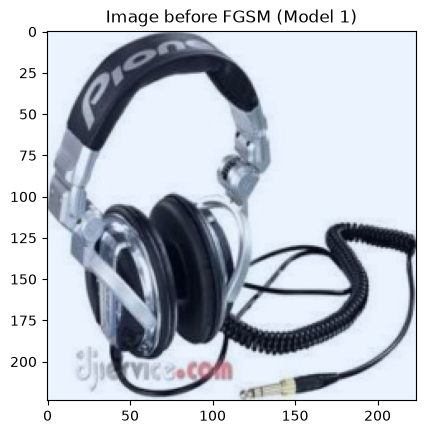

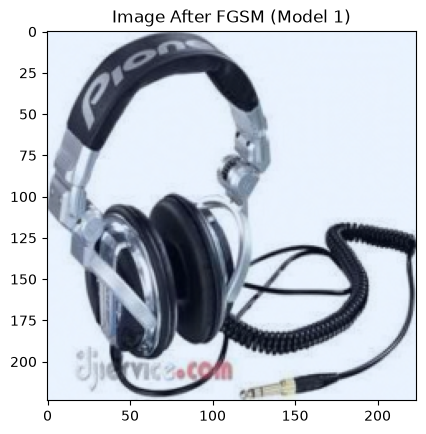

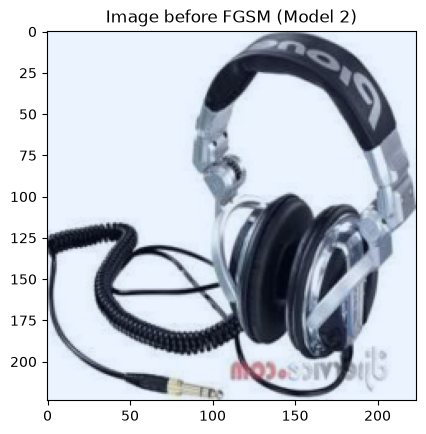

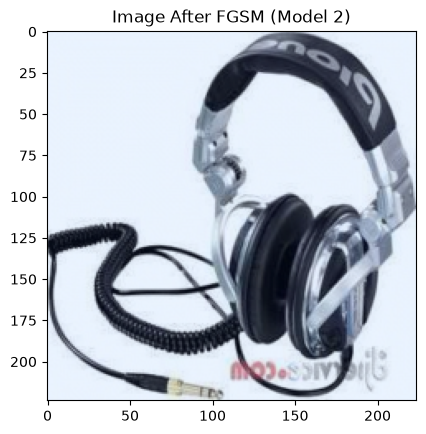

In [2]:
def new_img(image,gradient,epsilon):
    return image+epsilon*gradient.sign()

import sys

def clip(images):
    img = images.clone()
    img -= img.min()
    img /= (img.max() + 1e-7)
    return img






running_loss1=0
correct=0
total=0
running_loss1_2=0
correct2=0
model1.eval()
batch=0
gradients_1=[]
gradients_2=[]
for images,labels in test_loader:
    
    batch+=1
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output1=model1(images)
    loss1=criterion(output1,labels)
    model1.zero_grad()
    loss1.backward()
    running_loss1+=loss1.item()*labels.size(0)
    total+=labels.size(0)
    probability,classes=torch.max(output1,1)
    correct+=(labels==classes).sum().item()
    gradient_values=images.grad.abs().mean(dim=1)
    gradients_1.append(clip(gradient_values).cpu().detach().numpy()[0]) #first image
    if batch<2:
        plt.figure()
        plt.imshow(clip(images.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image before FGSM (Model 1)")

  
    adversary_img=new_img(images,images.grad,0.01)
    output1_2=model1(adversary_img)
    loss1_2=criterion(output1_2,labels)
    model1.zero_grad()
    loss1_2.backward()
    probability2,classes2=torch.max(output1_2,1)
    correct2+=(classes2==labels).sum().item()
    running_loss1_2+=loss1_2.item()*labels.size(0)
    if batch<2:
        plt.figure()
        plt.imshow(clip(adversary_img.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image After FGSM (Model 1)")

print("Before Injecting FGSM")
print(f"Model 1 Test Accuracy: {(correct/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1/total}")          
print("")
print("After Injecting FGSM")
print(f"Model 1 Test Accuracy: {(correct2/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1_2/total}")          
print("")
















running_loss2=0
correct=0
total=0
running_loss2_2=0
correct2=0
model2.eval()
batch=0
for images,labels in test_loader:
    batch+=1
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output2=model2(images)
    loss2=criterion(output2,labels)
    model2.zero_grad()
    loss2.backward()
    running_loss2+=loss2.item()*labels.size(0)
    total+=labels.size(0)
    probability,classes=torch.max(output2,1)
    correct+=(labels==classes).sum().item()
    gradient_values=images.grad.abs().mean(dim=1)
    gradients_2.append(clip(gradient_values).cpu().detach().numpy()[0]) #first image
    if batch<2:
        plt.figure()
        plt.imshow(clip(images.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image before FGSM (Model 2)")

    adversary_img=new_img(images,images.grad,0.01)
    output2_2=model2(adversary_img)
    loss2_2=criterion(output2_2,labels)
    model2.zero_grad()
    loss2_2.backward()
    probability2,classes2=torch.max(output2_2,1)
    correct2+=(classes2==labels).sum().item()
    running_loss2_2+=loss2_2.item()*labels.size(0)
    if batch<2:
        plt.figure()
        plt.imshow(clip(adversary_img.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image After FGSM (Model 2)")
print("Before Injecting FGSM")
print(f"Model 2 Test Accuracy: {(correct/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2/total}")          
print("")
print("After Injecting FGSM")
print(f"Model 2 Test Accuracy: {(correct2/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2_2/total}")          
print("")













Notice there's no difference in the images yet the accuracy significantly dropped

Text(0.5, 1.0, 'Saliency map Model(2)')

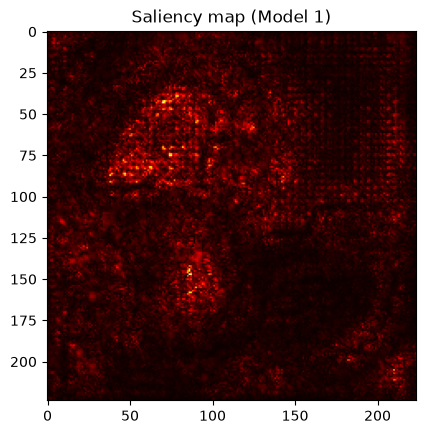

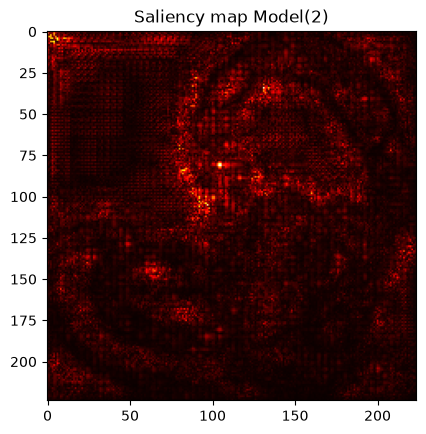

In [3]:
plt.figure()
plt.imshow(gradients_1[0],cmap="hot") #first image from the first batch
plt.title("Saliency map (Model 1)")



plt.figure()
plt.imshow(gradients_2[0],cmap="hot") #first image from the first batch
plt.title("Saliency map Model(2)")




Model 1 Test Accuracy: 90.09468317552805%
Model 1 Testing Loss: 0.33880325389967636


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Model 2 Test Accuracy: 88.56518572469045%
Model 2 Testing Loss: 0.5856794948484111


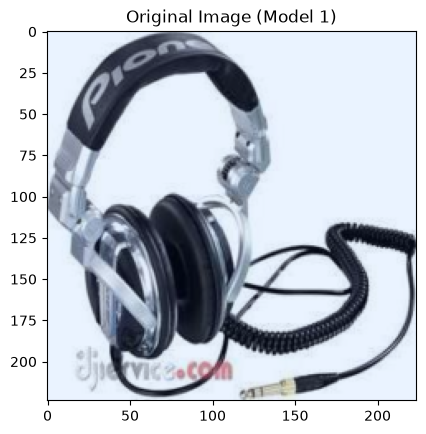

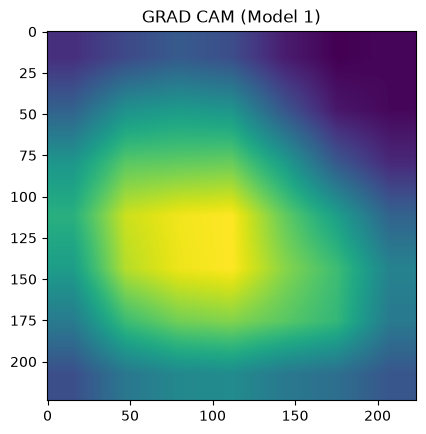

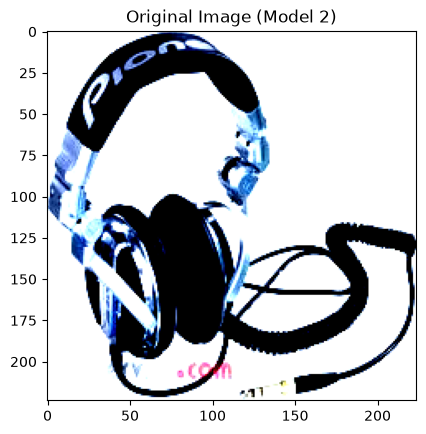

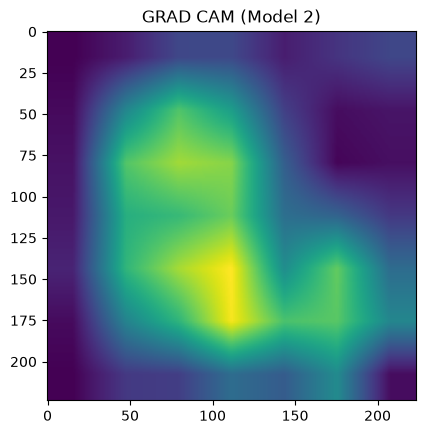

In [9]:
import torch.nn.functional as F
running_loss1=0
correct=0
total=0
running_loss1_2=0
correct2=0
model1.eval()
batch=0
gradients_1=[]
gradients_2=[]
feature_map=[[]]
grad_cam1=[]
def forward_hook(module,input,output):
    feature_map[0]=output
    feature_map[0].retain_grad()
model1.layer4.register_forward_hook(forward_hook)    
model2.features[-1].register_forward_hook(forward_hook)

for images,labels in test_loader:
    
    batch+=1
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output1=model1(images)
    loss1=criterion(output1,labels)
    model1.zero_grad()
    
    running_loss1+=loss1.item()*labels.size(0)
    total+=labels.size(0)
    probability,classes=torch.max(output1,1)
    correct+=(labels==classes).sum().item()
    if batch<2:
        class_score=output1[0,classes[0]] #first image
        class_score.backward()
        first_image_feature=feature_map[0][0]
        first_image_gradient_mean=feature_map[0][0].mean(dim=(1,2))
        first_image_gradient_weighted=first_image_gradient_mean[:,None,None]*first_image_feature #Broadcasting
        grad_cam1=first_image_gradient_weighted.sum(dim=0)
        grad_cam1=F.relu(grad_cam1)
        grad_cam1=grad_cam1.unsqueeze(0).unsqueeze(0)
        grad_cam1=F.interpolate(
            grad_cam1,
            size=(images[0].shape[1],images[0].shape[2]),
            mode="bilinear",
            align_corners=False
        )
        grad_cam1=grad_cam1.squeeze(0).squeeze(0)
        plt.figure()
        plt.imshow(clip(images[0]).permute(1,2,0).cpu().detach().numpy())
        plt.title("Original Image (Model 1)")
        plt.figure()
        plt.imshow(clip(grad_cam1).cpu().detach().numpy())
        plt.title("GRAD CAM (Model 1)")
    


   



    

print(f"Model 1 Test Accuracy: {(correct/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1/total}")          

















running_loss2=0
correct=0
total=0
running_loss2_2=0
correct2=0
model2.eval()
batch=0
grad_cam_2=[]
for images,labels in test_loader:
    batch+=1
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output2=model2(images)
    loss2=criterion(output2,labels)
    model2.zero_grad()
    loss2.backward()
    running_loss2+=loss2.item()*labels.size(0)
    total+=labels.size(0)
    probability,classes=torch.max(output2,1)
    correct+=(labels==classes).sum().item()
    if batch<2:
        class_score=output1[0,classes[0]] #first image
        class_score.backward()
        first_image_feature=feature_map[0][0]
        first_image_gradient_mean=feature_map[0][0].mean(dim=(1,2))
        first_image_gradient_weighted=first_image_gradient_mean[:,None,None]*first_image_feature #Broadcasting
        grad_cam_2=first_image_gradient_weighted.sum(dim=0)
        grad_cam_2=F.relu(grad_cam_2)
        grad_cam_2=grad_cam_2.unsqueeze(0).unsqueeze(0)
        grad_cam_2=F.interpolate(
            grad_cam_2,
            size=(images[0].shape[1],images[0].shape[2]),
            mode="bilinear",
            align_corners=False
        )
        grad_cam_2=grad_cam_2.squeeze(0).squeeze(0)
        plt.figure()
        plt.imshow(images[0].permute(1,2,0).cpu().detach().numpy())
        plt.title("Original Image (Model 2)")
        plt.figure()
        plt.imshow(grad_cam_2.cpu().detach().numpy())
        plt.title("GRAD CAM (Model 2)")
    

    

print(f"Model 2 Test Accuracy: {(correct/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2/total}")          





